## Analysis Results

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import (
    get_driver_hamiltonian,
    get_longitudinal_hamiltonian,
    computational_basis,
)
from src.schedule_utils import SchedulerModel, Schedule
from ManyBodyQutip.qutip_class import SpinOperator
from src.utils import Sector
import pickle
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from tqdm import trange
from scipy.sparse.linalg import eigsh, expm_multiply

nqubits = 6

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)

PS = Sector(nqubits=nqubits)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli tables for n=6 (4096 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=3 qubits (8d)
Sector: 32 states out of 64


In [2]:
with open(f"magic_annealing_results_qubit_{nqubits}_optimal_control.pkl", "rb") as f:
    data = pickle.load(f)

time = data["time"]
taus = data["tau_qs"]
spectrums = data["spectrums"]
energies = data["energies"]
probabilities_list = data["probabilities_list"]
psi_histories = data["psi_histories"]
eigenstates_histories = data["eigenstates_histories"]
magic_list = data["magic_list"]
entanglement_entropy_history_quench_list = data[
    "entanglement_entropy_history_quench_list"
]
histories = data["history"]
histories_drivings_driver = data["history_drivings_driver"]
histories_drivings_target = data["history_drivings_target"]
driver_hamiltonian_s = data["hamiltonian_driver"]
target_hamiltonian_s = data["hamiltonian_target"]
psi_init = data["psi_init"]

print(len(histories_drivings_driver[0][0]))

print(len(magic_list), len(magic_list[0]))

10
10 10


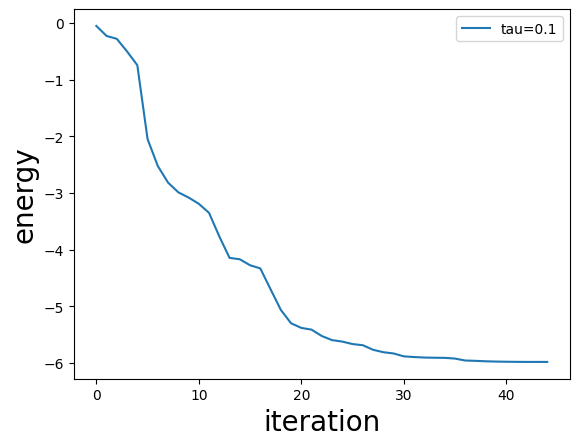

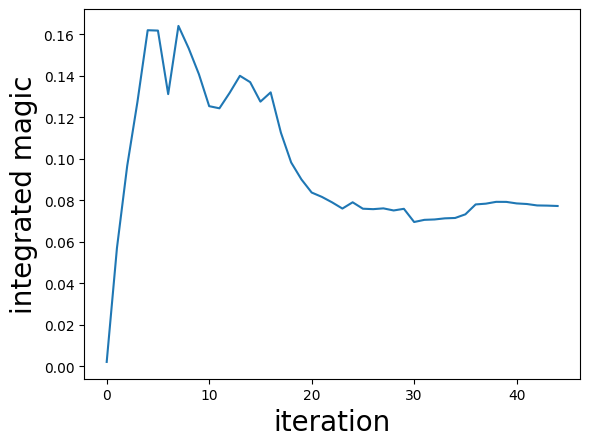

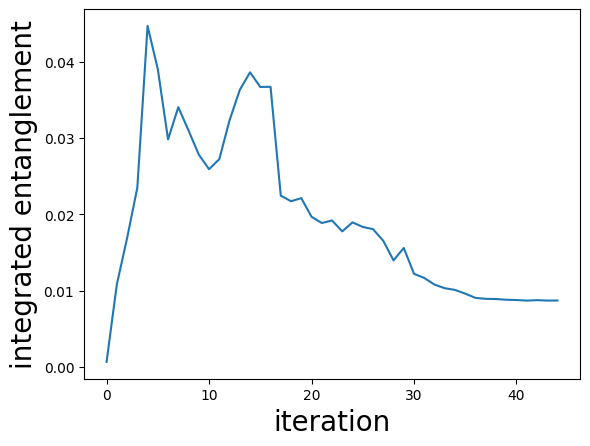

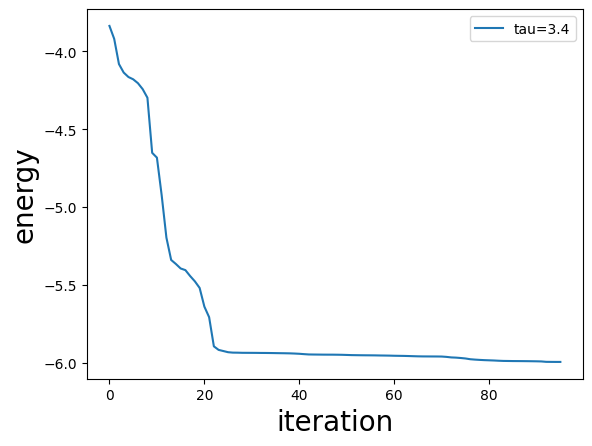

KeyboardInterrupt: 

In [3]:
for i, history in enumerate(histories):
    plt.plot(np.arange(len(history)), history, label=f"tau={taus[i]:.1f}")
    plt.xlabel("iteration", fontsize=20)
    plt.ylabel("energy", fontsize=20)
    # plt.yscale('log')
    plt.legend()
    plt.show()
    total_magic = []
    total_entanglement = []
    for j, h in enumerate(history):
        h_driver = histories_drivings_driver[i][j]
        h_target = histories_drivings_target[i][j]
        time = np.linspace(0, taus[i], int(100 * taus[i]))
        delta_t = time[1] - time[0]
        # initialization
        psi = psi_init.copy()
        magic = []
        entanglement = []
        for r, t in enumerate(time):
            hamiltonian_t = (
                h_driver[r] * driver_hamiltonian_s + target_hamiltonian_s * h_target[r]
            )
            psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
            magic.append(sre(PS.lift(psi)))
            entanglement.append(entanglement_entropy.von_neumann(PS.lift(psi)))
        total_magic.append(delta_t * np.sum(magic))
        total_entanglement.append(delta_t * np.sum(entanglement))

    plt.plot(np.arange(len(total_magic)), total_magic, label="magic")
    plt.xlabel("iteration", fontsize=20)
    plt.ylabel("integrated magic", fontsize=20)
    plt.show()
    plt.plot(
        np.arange(len(total_entanglement)), total_entanglement, label="entanglement"
    )
    plt.xlabel("iteration", fontsize=20)
    plt.ylabel("integrated entanglement", fontsize=20)
    plt.show()

In [ ]:
total_magic = []
total_entanglement = []
delta_t = model.tf / model.nsteps
print(len(model.history_drivings[0]))
for i in trange(0, len(model.history_drivings), 1):

    h_driver, h_target = model.history_drivings[i]

    # initialization
    psi = psi_init.copy()
    psi_history_optimalcontrol = np.zeros(
        (time_steps, psi_init.shape[0]), dtype=complex
    )
    magic = []
    entanglement = []
    for i, t in enumerate(time):
        hamiltonian_t = (
            h_driver[i] * driver_hamiltonian_s + target_hamiltonian_s * h_target[i]
        )
        psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
        psi_history_optimalcontrol[i] = psi
        magic.append(sre(PS.lift(psi)))
        entanglement.append(entanglement_entropy.von_neumann(PS.lift(psi)))
    total_magic.append(delta_t * np.sum(magic))
    total_entanglement.append(delta_t * np.sum(entanglement))